In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os

os.chdir('/content/drive/MyDrive')

os.listdir()

['155410_DE1_0_2008_to_2010_Inpatient_Claims_Sample_20.zip',
 'DE1_0_2008_to_2010_Inpatient_Claims_Sample_20.csv',
 'Colab Notebooks',
 'Copy of MSDS Degree Progress  (1).gdoc',
 'Copy of [MAKE A COPY] DS+X Student Waiver & Photo Release (1).docx.gdoc',
 'd_items.gsheet',
 'Copy of [MAKE A COPY] DS+X Student Waiver & Photo Release.docx.gdoc',
 'astika resume BU.pdf',
 'astika bu resume 2 (1).pdf',
 'bio celt.jpeg',
 'Copy of MSDS Degree Progress .gdoc',
 'Astika_Tyagi_Resume_CELT.pdf',
 'device-recall-0001-of-0001.json.zip',
 'recall_data']

In [7]:
import zipfile

with zipfile.ZipFile('device-recall-0001-of-0001.json.zip', 'r') as zip_ref:
    zip_ref.extractall('recall_data')

In [8]:
os.listdir('recall_data')

['device-recall-0001-of-0001.json']

In [9]:
import json
import pandas as pd
from pandas import json_normalize

with open('recall_data/device-recall-0001-of-0001.json') as f:
    data = json.load(f)

df = json_normalize(data['results'])

print(df.shape)
df.head()

(57511, 35)


,cfres_id,product_res_number,event_date_initiated,event_date_posted,recall_status,res_event_number,product_code,product_description,code_info,recalling_firm,...,openfda.regulation_number,openfda.device_class,address_2,event_date_terminated,firm_fei_number,other_submission_description,k_numbers,pma_numbers,event_date_created,openfda.pma_number
0,218307,Z-1472-2026,2026-01-21,2026-02-26,"Open, Classified",98332,FNM,"Adapt Pump, Model/Catalog Number: 61600200-Ada...",UDI-DI 0084569904914; All serial numbers with ...,Agiliti Health Ellis,...,880.5550,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,218406,Z-1462-2026,2026-01-14,2026-02-24,"Open, Classified",98303,KPL,"PIE PAK\nModels: P2HC-A, P2HC-S, P2HC",All Lots\nUDI:,Edermy LLC,...,876.5220,2,Ste A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,105069,Z-0389-2012,2011-09-19,2012-01-11,Terminated,60344,LFQO,Magnus Hybrid operating table columns 1180.01A...,"510 k EXEMPT 1180.01A1- Lot #0002, 0004, 0005...",Maquet Inc.,...,NaN,NaN,NaN,2011-12-08,NaN,NaN,NaN,NaN,NaN,NaN
3,105700,Z-0485-2012,2011-11-28,2012-01-11,Terminated,60528,RER,Raymond Laser alignment guide - Model #1096597...,Model #1096597/002,The Raymond Corporation S Canal,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,131624,Z-0604-2015,2014-11-17,2014-12-12,Terminated,69838,KOG,"PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...",37302 37858 39543 45622 48347 48903 49147 4914...,Stryker Endoscopy,...,NaN,NaN,NaN,2015-07-17,2936485,NaN,NaN,NaN,NaN,NaN


In [35]:
print(recalls.columns.tolist())

['cfres_id', 'product_res_number', 'event_date_initiated', 'event_date_posted', 'recall_status', 'res_event_number', 'product_code', 'product_description', 'code_info', 'recalling_firm', 'address_1', 'city', 'state', 'postal_code', 'additional_info_contact', 'reason_for_recall', 'root_cause_description', 'action', 'product_quantity', 'distribution_pattern', 'openfda_k_number', 'openfda_registration_number', 'openfda_fei_number', 'openfda_device_name', 'openfda_medical_specialty_description', 'openfda_regulation_number', 'openfda_device_class', 'address_2', 'event_date_terminated', 'firm_fei_number', 'other_submission_description', 'k_numbers', 'pma_numbers', 'event_date_created', 'openfda_pma_number', 'year']


In [36]:
for col in recalls.columns:
    print(col)

cfres_id
product_res_number
event_date_initiated
event_date_posted
recall_status
res_event_number
product_code
product_description
code_info
recalling_firm
address_1
city
state
postal_code
additional_info_contact
reason_for_recall
root_cause_description
action
product_quantity
distribution_pattern
openfda_k_number
openfda_registration_number
openfda_fei_number
openfda_device_name
openfda_medical_specialty_description
openfda_regulation_number
openfda_device_class
address_2
event_date_terminated
firm_fei_number
other_submission_description
k_numbers
pma_numbers
event_date_created
openfda_pma_number
year


In [37]:
recalls["reason_for_recall"].head(10)

,reason_for_recall
26,The X-ray safety and manufacturing date labels...
27,HORIBA custom configured fluorescence instrume...
28,Excessive ultraviolet-C radiation
57,The integrity of the product container may be ...
58,the Nominal Ocular Hazard Distance (NOHD) asso...
59,The User Remote Interlock Dongle provided with...
60,One manufacturing lot of a non-sterile pack wa...
61,The Virus Counter is an automated laboratory i...
68,The manufacturer identified a risk that their ...
69,The integrity of the product container may be ...


In [10]:
# inspect shape and columns
print(df.shape)
print(df.columns.tolist())

(57511, 35)
['cfres_id', 'product_res_number', 'event_date_initiated', 'event_date_posted', 'recall_status', 'res_event_number', 'product_code', 'product_description', 'code_info', 'recalling_firm', 'address_1', 'city', 'state', 'postal_code', 'additional_info_contact', 'reason_for_recall', 'root_cause_description', 'action', 'product_quantity', 'distribution_pattern', 'openfda.k_number', 'openfda.registration_number', 'openfda.fei_number', 'openfda.device_name', 'openfda.medical_specialty_description', 'openfda.regulation_number', 'openfda.device_class', 'address_2', 'event_date_terminated', 'firm_fei_number', 'other_submission_description', 'k_numbers', 'pma_numbers', 'event_date_created', 'openfda.pma_number']


In [12]:
# make a working copy
recalls = df.copy()

In [13]:
# standardize column names
recalls.columns = (
    recalls.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print(recalls.columns.tolist())

['cfres_id', 'product_res_number', 'event_date_initiated', 'event_date_posted', 'recall_status', 'res_event_number', 'product_code', 'product_description', 'code_info', 'recalling_firm', 'address_1', 'city', 'state', 'postal_code', 'additional_info_contact', 'reason_for_recall', 'root_cause_description', 'action', 'product_quantity', 'distribution_pattern', 'openfda_k_number', 'openfda_registration_number', 'openfda_fei_number', 'openfda_device_name', 'openfda_medical_specialty_description', 'openfda_regulation_number', 'openfda_device_class', 'address_2', 'event_date_terminated', 'firm_fei_number', 'other_submission_description', 'k_numbers', 'pma_numbers', 'event_date_created', 'openfda_pma_number']


In [14]:
# check which columns contain lists
list_cols = [
    col for col in recalls.columns
    if recalls[col].apply(lambda x: isinstance(x, list)).any()
]

print("Columns with list values:")
print(list_cols)

Columns with list values:
['openfda_k_number', 'openfda_registration_number', 'openfda_fei_number', 'k_numbers', 'pma_numbers', 'openfda_pma_number']


In [15]:
# convert list-valued columns to strings so pandas can hash them
for col in list_cols:
    recalls[col] = recalls[col].apply(
        lambda x: "|".join(map(str, x)) if isinstance(x, list) else x
    )

# now remove exact duplicates
recalls = recalls.drop_duplicates()

print("Shape after dropping duplicates:", recalls.shape)

Shape after dropping duplicates: (57511, 35)


In [16]:
print("Total rows:", len(recalls))
print("Unique recall events:", recalls["cfres_id"].nunique())

Total rows: 57511
Unique recall events: 57503


No exact duplicates were detected. The dataset contains 57,511 rows representing 57,503 unique recall events, meaning a few recalls involve multiple products.

In FDA recall data, one recall event can appear multiple times because:

A recall can involve multiple products

Each product appears as a separate row

In [18]:
print("Missing cfres_id rows:", recalls["cfres_id"].isna().sum())

Missing cfres_id rows: 8


In [19]:
actual_dup_cfres = recalls[
    recalls["cfres_id"].notna() &
    recalls.duplicated(subset=["cfres_id"], keep=False)
].sort_values("cfres_id")

print(actual_dup_cfres)
print("Number of rows with duplicated non-null cfres_id:", len(actual_dup_cfres))

Empty DataFrame
Columns: [cfres_id, product_res_number, event_date_initiated, event_date_posted, recall_status, res_event_number, product_code, product_description, code_info, recalling_firm, address_1, city, state, postal_code, additional_info_contact, reason_for_recall, root_cause_description, action, product_quantity, distribution_pattern, openfda_k_number, openfda_registration_number, openfda_fei_number, openfda_device_name, openfda_medical_specialty_description, openfda_regulation_number, openfda_device_class, address_2, event_date_terminated, firm_fei_number, other_submission_description, k_numbers, pma_numbers, event_date_created, openfda_pma_number]
Index: []

[0 rows x 35 columns]
Number of rows with duplicated non-null cfres_id: 0


In [20]:
dup_ids = recalls.loc[recalls["cfres_id"].notna(), "cfres_id"]
dup_ids = dup_ids[dup_ids.duplicated()].unique()

print("Duplicated non-null cfres_id values:", dup_ids)
print("Count:", len(dup_ids))

Duplicated non-null cfres_id values: []
Count: 0


In [21]:
recalls = recalls.dropna(subset=["cfres_id"])

print("Shape after removing missing cfres_id:", recalls.shape)

Shape after removing missing cfres_id: (57503, 35)


In [22]:
print("Missing cfres_id:", recalls["cfres_id"].isna().sum())
print("Total rows:", len(recalls))
print("Unique cfres_id:", recalls["cfres_id"].nunique())

Missing cfres_id: 0
Total rows: 57503
Unique cfres_id: 57503


analyzing data after 2015-2025

In [23]:
recalls["event_date_initiated"] = pd.to_datetime(recalls["event_date_initiated"], errors="coerce")

recalls = recalls[
    (recalls["event_date_initiated"] >= "2015-01-01") &
    (recalls["event_date_initiated"] <= "2025-12-31")
]

dataset size after filtering

In [24]:
print("Rows:", recalls.shape[0])
print("Columns:", recalls.shape[1])

Rows: 31073
Columns: 35


In [25]:
print(recalls["event_date_initiated"].min())
print(recalls["event_date_initiated"].max())

2015-01-02 00:00:00
2025-12-31 00:00:00


Missing data analysis

In [26]:
recalls.isnull().sum().sort_values(ascending=False)

,0
pma_numbers,29317
address_2,27306
openfda_pma_number,27176
other_submission_description,27016
event_date_created,17695
event_date_posted,13378
event_date_terminated,12908
k_numbers,10765
firm_fei_number,9973
additional_info_contact,4600


In [27]:
print("Missing cfres_id:", recalls["cfres_id"].isna().sum())
print("Unique recall IDs:", recalls["cfres_id"].nunique())

Missing cfres_id: 0
Unique recall IDs: 31073


Device Category Distribution

In [28]:
recalls["product_code"].value_counts().head(20)

,count
product_code,
LRO,775
JAK,566
OWB,524
LNH,508
FPA,506
FSY,430
HSB,426
JWH,407
DQY,320


Recall status distribution - gives insight into the recall lifecycle

In [29]:
recalls["recall_status"].value_counts()

,count
recall_status,
Terminated,18200
"Open, Classified",12506
Completed,367


Time series trend


Extracts the year from the recall start date

In [30]:
recalls["year"] = recalls["event_date_initiated"].dt.year

Counts how many recalls happened in each year

How many medical device recalls happened each year between 2015-2025?

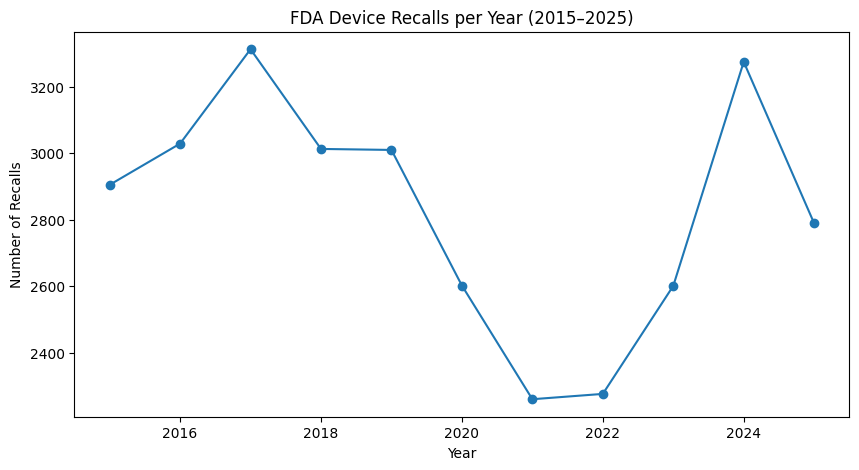

In [31]:
import matplotlib.pyplot as plt

recalls_per_year = recalls["year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
recalls_per_year.plot(kind="line", marker="o")
plt.title("FDA Device Recalls per Year (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Recalls")
plt.show()

In [32]:
recalls["openfda_device_class"].value_counts()

,count
openfda_device_class,
2,23407
1,5275
3,1632
N,243
U,222
f,7


<Axes: xlabel='openfda_device_class'>

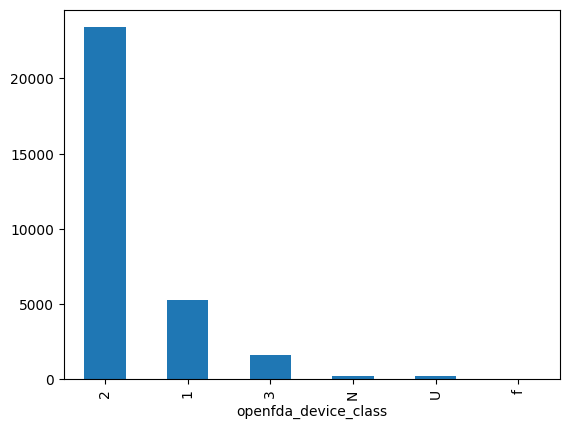

In [33]:
recalls["openfda_device_class"].value_counts().plot(kind="bar")

<Figure size 1000x600 with 0 Axes>

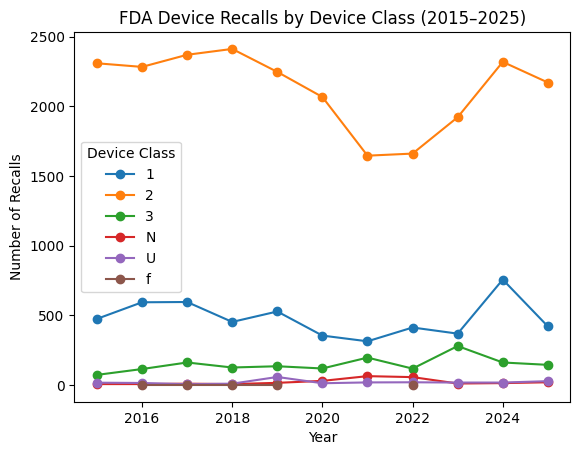

In [39]:
recalls_by_class_year = (
    recalls.groupby(["year", "openfda_device_class"])
    .size()
    .unstack()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
recalls_by_class_year.plot(marker="o")

plt.title("FDA Device Recalls by Device Class (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Recalls")
plt.legend(title="Device Class")

plt.show()

ROOT CAUSE ANALYSIS

What are the most common problems reported?

In [34]:
recalls["root_cause_description"].value_counts().head(15)

,count
root_cause_description,
Under Investigation by firm,6165
Device Design,4232
Process control,4213
Nonconforming Material/Component,3046
Software design,1781
Packaging,1039
Other,860
Component design/selection,793
No Marketing Application,680


**later we can run nlp on this field maybe

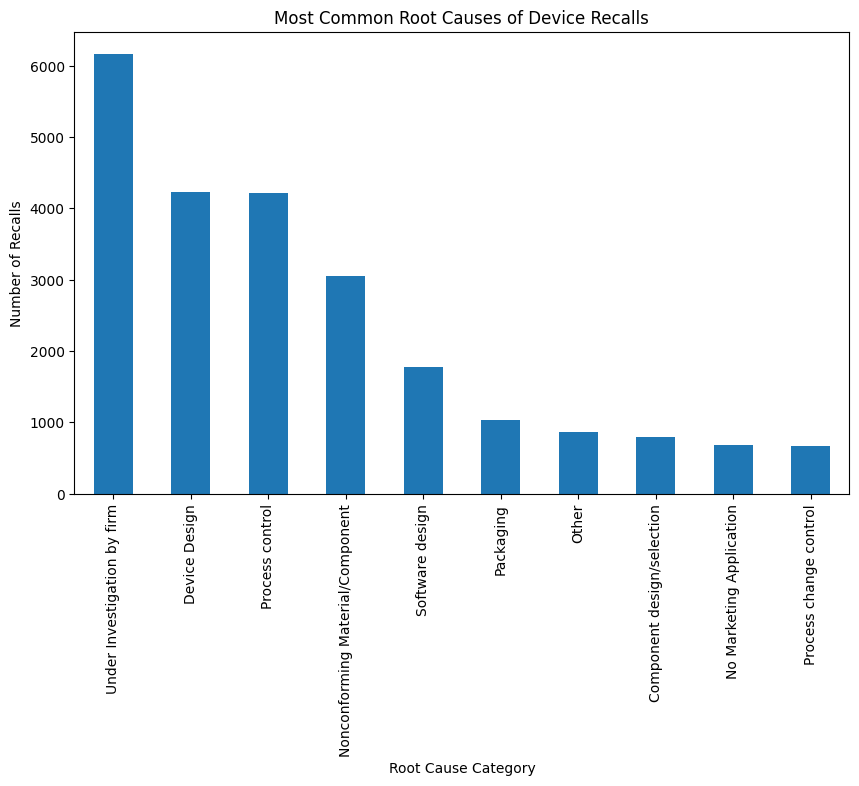

In [41]:
recalls["root_cause_description"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Most Common Root Causes of Device Recalls")
plt.xlabel("Root Cause Category")
plt.ylabel("Number of Recalls")
plt.show()

In [45]:
recalls["cfres_id"].is_unique

True

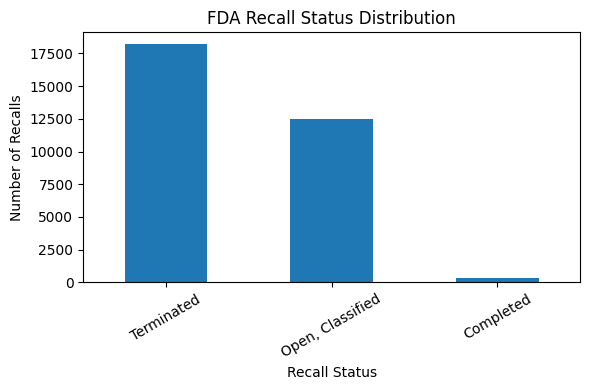

In [46]:
import matplotlib.pyplot as plt

status_counts = recalls["recall_status"].value_counts()

plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")

plt.title("FDA Recall Status Distribution")
plt.xlabel("Recall Status")
plt.ylabel("Number of Recalls")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

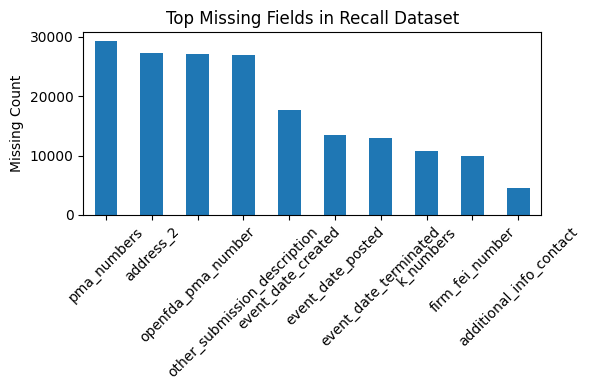

In [47]:
missing = recalls.isnull().sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
missing.plot(kind="bar")

plt.title("Top Missing Fields in Recall Dataset")
plt.ylabel("Missing Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
recalls[["cfres_id","product_code","root_cause_description"]].agg(["count","nunique"])

,cfres_id,product_code,root_cause_description
count,31073,31064,31063
nunique,31073,2123,43


In [49]:
recalls["product_code"].nunique()

2123